# Load
- loading precossed data

In [1]:
import pickle
import os, sys
from datetime import datetime
sys.path.append('./cs16')

# Import Extractors (previously named PPBC)
from Extractors import (
    Renyi2Extractor, ShannonExtractor, DivergenceExtractor,
    EnergyExtractor, CosineExtractor
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def load_preprocessed_data(save_path='preprocessed_data', filename='single_data.pkl'):
    """
    Load preprocessed data from a pickle file.

    Parameters
    ----------
    save_path : str, default='preprocessed_data'
        Directory containing the pickle file.
    filename : str, default='single_data.pkl'
        Name of the pickle file.

    Returns
    -------
    data : dict
        Dictionary containing all saved variables.
    """
    filepath = os.path.join(save_path, filename)

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")

    with open(filepath, 'rb') as f:
        data = pickle.load(f)

    print(f"✅ Data loaded from {filepath}")
    print(f"   Timestamp: {data.get('timestamp', 'unknown')}")
    print(f"   Keys: {list(data.keys())}")

    return data

In [2]:
# Load Preprocessed Data 
#(Text: NLP processed, Image: flatted)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
 
    # Load Data
data = load_preprocessed_data(
    save_path='preprocessed_data',
    filename='single_data.pkl'
)
    
# Extracting variables
X_train_polar = data['X_train_polar']
X_val_polar = data['X_val_polar']
X_test_polar = data['X_test_polar']
y_train_polar = data['y_train_polar']
y_val_polar = data['y_val_polar']
y_test_polar = data['y_test_polar']

X_train_image = data['X_train_image']
X_val_image = data['X_val_image']
X_test_image = data['X_test_image']

X_train_text= data['X_train_text']
X_val_text= data['X_val_text']
X_test_text= data['X_test_text']

y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']

✅ Data loaded from preprocessed_data\single_data.pkl
   Timestamp: 2026-03-01 21:37:50
   Keys: ['timestamp', 'description', 'X_train_polar', 'X_val_polar', 'X_test_polar', 'y_train_polar', 'y_val_polar', 'y_test_polar', 'X_train_text', 'X_val_text', 'X_test_text', 'y_train_text', 'y_val_text', 'y_test_text', 'X_train_image', 'X_val_image', 'X_test_image', 'y_train_image', 'y_val_image', 'y_test_image', 'y_train', 'y_val', 'y_test', 'num_classes', 'image_size', 'random_state']


# CNN:image, LSTM: text

In [4]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Softmax
from tensorflow.keras.models import Model
import numpy as np

# ----- Text branch -----
text_input = Input(shape=(200,), name='text_input')
t = Embedding(input_dim=10000, output_dim=100)(text_input)
t = LSTM(64, activation='tanh')(t)
text_branch = Dense(64, activation='tanh')(t)
text_out = Dense(3, activation='softmax', name='text_softmax')(text_branch)

# ----- Image branch -----
image_input = Input(shape=(64, 64, 3), name='image_input')
i = Conv2D(64, (3, 3), activation='relu', padding='same')(image_input)
i = MaxPooling2D(pool_size=(2, 2))(i)
i = Conv2D(128, (3, 3), activation='relu', padding='same')(i)
i = MaxPooling2D(pool_size=(2, 2))(i)
i = BatchNormalization()(i)
i = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
i = Dropout(0.5)(i)
i = MaxPooling2D(pool_size=(2, 2))(i)
i = BatchNormalization()(i)
i = Flatten()(i)
image_branch = Dense(64, activation='relu')(i)
image_out = Dense(3, activation='softmax', name='image_softmax')(image_branch)

# ----- Define Output model-----
model = Model(inputs=[text_input, image_input], outputs=[text_out, image_out])

# compile
model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

# ---- Training
history = model.fit(
    [X_train_text, X_train_image], 
    [y_train, y_train],       # 如果兩分支label一樣就傳一份，否則可分開
    validation_data=([X_val_text, X_val_image], [y_val, y_val]),
    epochs=10,
    batch_size=64
)

# ----- Prediction & Late Fusion -----
# seperate Probs
text_probs, image_probs = model.predict([X_test_text, X_test_image])
# Late Fusion：AVG
ensemble_probs = (text_probs + image_probs) / 2.0
predictions = np.argmax(ensemble_probs, axis=1)
true_labels = np.argmax(y_test, axis=1)
print(classification_report(true_labels, predictions, digits=4))

Epoch 1/10
61/61 [==============================] - 32s 483ms/step - loss: 2.1917 - text_softmax_loss: 0.9832 - image_softmax_loss: 1.2086 - text_softmax_accuracy: 0.5463 - image_softmax_accuracy: 0.4719 - val_loss: 1.9887 - val_text_softmax_loss: 0.9471 - val_image_softmax_loss: 1.0417 - val_text_softmax_accuracy: 0.5503 - val_image_softmax_accuracy: 0.4887
Epoch 2/10
61/61 [==============================] - 28s 456ms/step - loss: 1.7159 - text_softmax_loss: 0.7159 - image_softmax_loss: 1.0001 - text_softmax_accuracy: 0.6770 - image_softmax_accuracy: 0.5284 - val_loss: 2.1896 - val_text_softmax_loss: 0.9408 - val_image_softmax_loss: 1.2488 - val_text_softmax_accuracy: 0.5791 - val_image_softmax_accuracy: 0.5462
Epoch 3/10
61/61 [==============================] - 27s 444ms/step - loss: 1.3542 - text_softmax_loss: 0.3952 - image_softmax_loss: 0.9590 - text_softmax_accuracy: 0.8436 - image_softmax_accuracy: 0.5489 - val_loss: 2.2280 - val_text_softmax_loss: 1.1204 - val_image_softmax_los

# Save the Fused representation

In [5]:
# Concatenate and then save 
X_fused = np.concatenate([text_probs, image_probs], axis=1)  # (N, 6)

with open('cache/CNN_LSTM.pkl', 'wb') as f:
    pickle.dump(X_fused, f)


In [7]:
import numpy as np
from Extractors import ShannonExtractor
from sklearn.metrics import classification_report

# Convert one-hot labels to integer class indices
y_train_int = np.argmax(y_train, axis=1)
y_val_int   = np.argmax(y_val,   axis=1)
y_test_int  = np.argmax(y_test,  axis=1)

# Initialize a Shannon extractor (training‑free)
shannon_ext = ShannonExtractor(beta=0.5)

# Get predictions on the fused test features
shannon_pred = shannon_ext.predict(X_fused)

# Evaluate performance
print(classification_report(
    y_test_int, shannon_pred,
    digits=4,
    target_names=['negative', 'neutral', 'positive']
))


              precision    recall  f1-score   support

    negative     0.2676    0.2468    0.2568        77
     neutral     0.7077    0.6619    0.6840       278
    positive     0.4487    0.5303    0.4861       132

    accuracy                         0.5606       487
   macro avg     0.4747    0.4796    0.4756       487
weighted avg     0.5679    0.5606    0.5628       487



# Load X_fused

In [8]:
with open('cache/CNN_LSTM.pkl', 'rb') as f:
    X_fused = pickle.load(f)

X_fused

array([[2.2533594e-02, 6.1742049e-01, 3.6004591e-01, 1.5473585e-01,
        3.4237528e-01, 5.0288880e-01],
       [5.9173806e-05, 9.9993658e-01, 4.2756110e-06, 8.7389059e-02,
        6.0793394e-01, 3.0467701e-01],
       [2.0130419e-03, 9.9518895e-01, 2.7980416e-03, 2.2192596e-01,
        3.0186266e-01, 4.7621137e-01],
       ...,
       [2.0385369e-04, 9.9653256e-01, 3.2635850e-03, 5.8967970e-02,
        1.5018408e-01, 7.9084796e-01],
       [2.1933992e-03, 9.5658767e-01, 4.1218925e-02, 2.4565278e-01,
        2.3504874e-01, 5.1929843e-01],
       [4.9044067e-01, 1.2746771e-02, 4.9681252e-01, 1.6466989e-01,
        1.9767572e-01, 6.3765436e-01]], dtype=float32)

In [9]:
import numpy as np
y_train_int = np.argmax(y_train, axis=1)
y_val_int   = np.argmax(y_val,   axis=1)
y_test_int  = np.argmax(y_test,  axis=1)


In [27]:
# Import Extractors (previously PPBC)
from Extractors import (
    ShannonExtractor, Renyi2Extractor, DivergenceExtractor,
    EnergyExtractor, CosineExtractor
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Initialize extractors – they require no training (training‑free diagnostics)
extractors = {
    'shannon': ShannonExtractor(beta=1),
    'renyi2': Renyi2Extractor(beta=0.01),
    'jsd': DivergenceExtractor(mode="jsd", beta=1.0),
    'kl': DivergenceExtractor(mode="kl", beta=1.0),
    'hellinger': DivergenceExtractor(mode="hellinger", beta=1),
    'energy': EnergyExtractor(tau=1.1, smooth_alpha=1e-8),
    'cosine': CosineExtractor(gamma=1, center=False, smooth_alpha=1e-5)
}

# Evaluate each extractor on the test set (using fused probabilities)
best_f1 = 0
best_name = ""
best_preds = None

print("Extractor Evaluation on Test Set")
print("-" * 50)
for name, ext in extractors.items():
    # Extractors directly output predictions (or diagnostics) without fitting
    # .predict() may return class labels or diagnostic scores depending on your implementation
    preds = ext.predict(X_fused)                # X_fused should be your test fused features
    acc = accuracy_score(y_test_int, preds)
    f1 = f1_score(y_test_int, preds, average='weighted')
    print(f"{name:10s} | Weighted-F1: {f1:.4f} | Accuracy: {acc:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_acc = acc
        best_name = name
        best_preds = preds

print("\n" + "="*50)
print(f"Best Extractor: {best_name}")
print(f"  Weighted-F1: {best_f1:.4f}")
print(f"  Accuracy: {best_acc:.4f}")

Extractor Evaluation on Test Set
--------------------------------------------------
shannon    | Weighted-F1: 0.5628 | Accuracy: 0.5606
renyi2     | Weighted-F1: 0.3783 | Accuracy: 0.3984
jsd        | Weighted-F1: 0.5677 | Accuracy: 0.5626
kl         | Weighted-F1: 0.4945 | Accuracy: 0.4990
hellinger  | Weighted-F1: 0.5589 | Accuracy: 0.5544
energy     | Weighted-F1: 0.5607 | Accuracy: 0.5585
cosine     | Weighted-F1: 0.5291 | Accuracy: 0.5359

Best Extractor: jsd
  Weighted-F1: 0.5677
  Accuracy: 0.5626


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

def plot_prediction_agreement(extractors, X_fused, y_test_int):
    """
    Visualise the pairwise agreement among extractor predictions.
    Lower agreement indicates higher complementarity – extractors make 
    different decisions on the same samples, offering diverse behaviours 
    for DMS to exploit.
    
    Parameters
    ----------
    extractors : dict
        Dictionary of extractor instances, each with a .predict() method.
    X_fused : np.ndarray
        Fused probability features, shape (n_samples, n_features).
    y_test_int : np.ndarray
        True integer labels (used for optional accuracy reporting, not shown here).
    
    Returns
    -------
    agreement : np.ndarray
        Pairwise agreement matrix (n_extractors × n_extractors).
    """
    
    # Obtain predictions from all extractors
    predictions = {}
    for name, ext in extractors.items():
        preds = ext.predict(X_fused)
        predictions[name] = preds
    
    names = list(predictions.keys())
    n_extractors = len(names)
    
    # Compute pairwise agreement matrix
    agreement = np.zeros((n_extractors, n_extractors))
    for i, name_i in enumerate(names):
        for j, name_j in enumerate(names):
            agreement[i, j] = np.mean(predictions[name_i] == predictions[name_j])
    
    # Visualise the agreement matrix (upper triangle masked for clarity)
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(agreement, dtype=bool), k=1)
    sns.heatmap(agreement, mask=mask, annot=True, fmt='.3f',
                xticklabels=names, yticklabels=names,
                cmap='YlOrRd', vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'Prediction Agreement'})
    plt.title('Extractor Prediction Agreement Matrix\n(Lower agreement = Higher complementarity)',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Identify most complementary pairs (lowest agreement)
    print("\n🔍 Most Complementary Extractor Pairs (Lowest Agreement):")
    agreements = []
    for i in range(n_extractors):
        for j in range(i+1, n_extractors):
            agreements.append((names[i], names[j], agreement[i, j]))
    
    agreements.sort(key=lambda x: x[2])
    for idx, (ext1, ext2, agree) in enumerate(agreements[:5]):
        print(f"  {idx+1}. {ext1} & {ext2}: {agree:.3f} agreement")
    
    return agreement

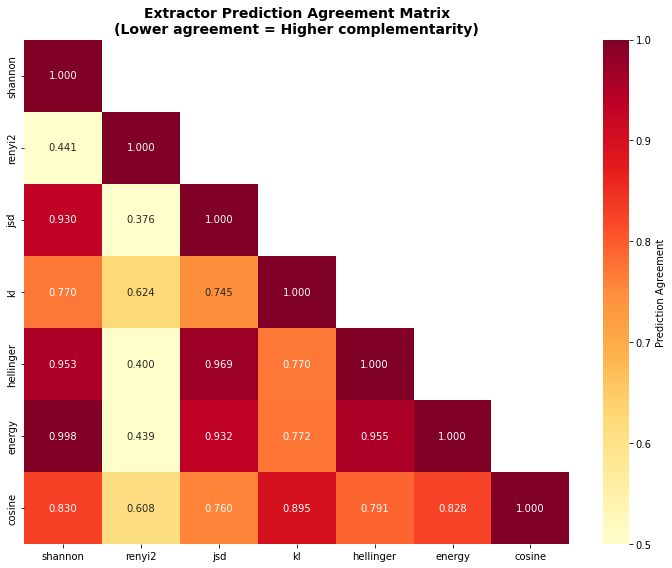


🔍 Most Complementary Extractor Pairs (Lowest Agreement):
  1. renyi2 & jsd: 0.376 agreement
  2. renyi2 & hellinger: 0.400 agreement
  3. renyi2 & energy: 0.439 agreement
  4. shannon & renyi2: 0.441 agreement
  5. renyi2 & cosine: 0.608 agreement


array([[1.        , 0.44147844, 0.9301848 , 0.77002053, 0.95277207,
        0.99794661, 0.82956879],
       [0.44147844, 1.        , 0.37577002, 0.62422998, 0.40041068,
        0.43942505, 0.60780287],
       [0.9301848 , 0.37577002, 1.        , 0.74537988, 0.96919918,
        0.93223819, 0.75975359],
       [0.77002053, 0.62422998, 0.74537988, 1.        , 0.77002053,
        0.77207392, 0.89527721],
       [0.95277207, 0.40041068, 0.96919918, 0.77002053, 1.        ,
        0.95482546, 0.79055441],
       [0.99794661, 0.43942505, 0.93223819, 0.77207392, 0.95482546,
        1.        , 0.8275154 ],
       [0.82956879, 0.60780287, 0.75975359, 0.89527721, 0.79055441,
        0.8275154 , 1.        ]])

In [12]:
plot_prediction_agreement(extractors, X_fused, y_test_int)

In [13]:
from sklearn.manifold import MDS

def plot_extractor_mds(extractors, X_fused, y_test_int):
    """
    Project extractors into a 2D space using Multidimensional Scaling (MDS).
    
    The distance between any two extractors is defined as 1 - prediction agreement.
    Points that are closer together make more similar predictions (potential redundancy),
    while those farther apart are more complementary (useful for DMS diversity).
    
    Parameters
    ----------
    extractors : dict
        Dictionary of extractor instances, each with a .predict() method.
    X_fused : np.ndarray
        Fused probability features, shape (n_samples, n_features).
    y_test_int : np.ndarray
        True integer labels (not directly used, but kept for interface consistency).
    
    Returns
    -------
    coords : np.ndarray
        2D coordinates of each extractor from MDS, shape (n_extractors, 2).
    distance_matrix : np.ndarray
        Pairwise distance matrix (1 - agreement), shape (n_extractors, n_extractors).
    """
    
    # Obtain predictions from all extractors
    predictions = []
    names = []
    for name, ext in extractors.items():
        preds = ext.predict(X_fused)
        predictions.append(preds)
        names.append(name)
    
    n_extractors = len(names)
    
    # Compute pairwise distance = 1 - agreement rate
    distance_matrix = np.zeros((n_extractors, n_extractors))
    for i in range(n_extractors):
        for j in range(n_extractors):
            distance_matrix[i, j] = 1 - np.mean(predictions[i] == predictions[j])
    
    # Apply MDS to obtain 2D coordinates
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(distance_matrix)
    
    # Visualise the extractor complementarity map
    plt.figure(figsize=(10, 8))
    
    # Plot extractor points
    scatter = plt.scatter(coords[:, 0], coords[:, 1], s=500,
                         c=range(n_extractors), cmap='tab10', alpha=0.8)
    
    # Annotate each point with the extractor name
    for i, name in enumerate(names):
        plt.annotate(name, (coords[i, 0], coords[i, 1]),
                    fontsize=11, fontweight='bold',
                    ha='center', va='center')
    
    # Draw connections for similar extractors (distance < 0.3)
    for i in range(n_extractors):
        for j in range(i+1, n_extractors):
            dist = distance_matrix[i, j]
            if dist < 0.3:
                plt.plot([coords[i, 0], coords[j, 0]],
                        [coords[i, 1], coords[j, 1]],
                        'gray', alpha=0.3, linewidth=2*(1-dist))
    
    plt.title('Extractor Complementarity Map (MDS Projection)\nCloser = More Similar Predictions',
              fontsize=14, fontweight='bold')
    plt.xlabel('MDS Dimension 1')
    plt.ylabel('MDS Dimension 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return coords, distance_matrix

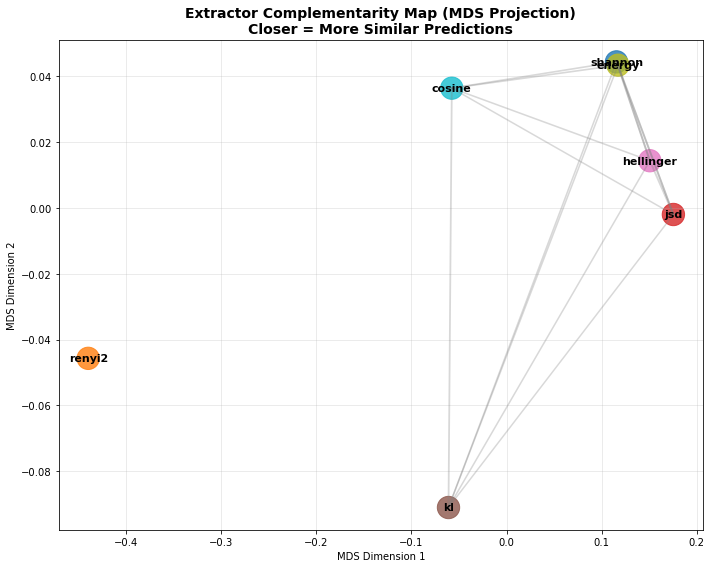

In [15]:
coords, dist_mat = plot_extractor_mds(extractors, X_fused, y_test_int)

In [19]:
def extract_and_save_cnnlstm_features(
    X_train_text, X_train_image,
    X_val_text, X_val_image,
    X_test_text, X_test_image,
    y_train, y_val, y_test,
    save_path="cache",
    filename="s_cnnlstm.pkl",
    epochs=10,
    batch_size=64
):
    """
    Train a CNN-LSTM encoder, extract features, and save them in the same format 
    as ExtraTree outputs.
    """

    print("="*60)
    print("🚀 Training CNN-LSTM Encoder")
    print("="*60)

    # Convert labels to integer form (for metrics)
    y_train_int = np.argmax(y_train, axis=1)
    y_val_int = np.argmax(y_val, axis=1)
    y_test_int = np.argmax(y_test, axis=1)

    # Build models
    model, feature_extractor = build_cnn_lstm_encoder()

    # Compile – note: two outputs require loss_weights
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        loss_weights=[1.0, 1.0],  # both outputs share equal weight
        metrics=['accuracy']
    )

    # Train – note: provide labels for both outputs
    history = model.fit(
        [X_train_text, X_train_image],
        [y_train, y_train],  # same labels for both branches
        validation_data=([X_val_text, X_val_image], [y_val, y_val]),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    print("\n" + "="*60)
    print("📊 Extracting features...")
    print("="*60)

    # Extract all required outputs
    train_outputs = feature_extractor.predict([X_train_text, X_train_image], batch_size=batch_size, verbose=1)
    val_outputs = feature_extractor.predict([X_val_text, X_val_image], batch_size=batch_size, verbose=1)
    test_outputs = feature_extractor.predict([X_test_text, X_test_image], batch_size=batch_size, verbose=1)

    # Obtain per-modality probabilities
    train_probs_text = train_outputs['text_probs']
    train_probs_image = train_outputs['image_probs']

    val_probs_text = val_outputs['text_probs']
    val_probs_image = val_outputs['image_probs']

    test_probs_text = test_outputs['text_probs']
    test_probs_image = test_outputs['image_probs']

    # Obtain fused features (needed by DPF)
    X_train_global = train_outputs['fused_features']
    X_val_global = val_outputs['fused_features']
    X_test_global = test_outputs['fused_features']

    # ========== Prediction section (adjusted) ==========
    # Method 1: use predictions from the text branch
    test_pred_text = np.argmax(test_probs_text, axis=1)
    test_pred_image = np.argmax(test_probs_image, axis=1)

    # Option: use text predictions (or averaging)
    # Here we use text predictions
    test_pred = test_pred_text

    # Method 2: average the two modalities
    # test_pred_probs = (test_probs_text + test_probs_image) / 2
    # test_pred = np.argmax(test_pred_probs, axis=1)

    # Compute accuracy
    test_accuracy = accuracy_score(y_test_int, test_pred)

    print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")
    print(f"   Text accuracy: {accuracy_score(y_test_int, test_pred_text):.4f}")
    print(f"   Image accuracy: {accuracy_score(y_test_int, test_pred_image):.4f}")

    # ========== Build results dictionary ==========
    results = {
        # labels
        "y_train_int": y_train_int,
        "y_val_int": y_val_int,
        "y_test_int": y_test_int,

        # unimodal probabilities
        "train_probs_text": train_probs_text,
        "val_probs_text": val_probs_text,
        "test_probs_text": test_probs_text,

        "train_probs_image": train_probs_image,
        "val_probs_image": val_probs_image,
        "test_probs_image": test_probs_image,

        # DPF fused features
        "X_train_global": X_train_global,
        "X_val_global": X_val_global,
        "X_test_global": X_test_global,

        # extra information
        "train_text_features": train_outputs['text_features'],
        "train_image_features": train_outputs['image_features'],
        "fused_feature_dim": X_train_global.shape[1],

        # metrics
        "test_pred": test_pred,
        "test_accuracy": test_accuracy,
        "classification_report": classification_report(
            y_test_int,
            test_pred,
            digits=4,
            target_names=['negative', 'neutral', 'positive'],
            output_dict=True
        ),

        # training info
        "training_history": history.history,
        "epochs": epochs,
        "batch_size": batch_size,

        # timing
        "elapsed_time_sec": None,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "encoder_type": "cnn_lstm"
    }

    # Save to cache
    os.makedirs(save_path, exist_ok=True)
    filepath = os.path.join(save_path, filename)

    with open(filepath, "wb") as f:
        pickle.dump(results, f)

    print("\n" + "="*60)
    print(f"✅ All CNN-LSTM features saved to: {filepath}")
    print("="*60)
    print(f"📊 Feature shapes:")
    print(f"   X_train_global: {X_train_global.shape}")
    print(f"   train_probs_text: {train_probs_text.shape}")
    print(f"   train_probs_image: {train_probs_image.shape}")
    print(f"📈 Test Accuracy: {test_accuracy:.4f}")
    print("="*60)

    return results


# ============================================================
# Simpler version: use feature_extractor to directly obtain predictions
# ============================================================

def extract_and_save_cnnlstm_features_v2(
    X_train_text, X_train_image,
    X_val_text, X_val_image,
    X_test_text, X_test_image,
    y_train, y_val, y_test,
    save_path="cache",
    filename="s_cnnlstm.pkl",
    epochs=10,
    batch_size=64
):
    """Simplified version – uses feature_extractor to retrieve all outputs in one step."""

    print("="*60)
    print("🚀 Training CNN-LSTM Encoder")
    print("="*60)

    # Convert labels
    y_train_int = np.argmax(y_train, axis=1)
    y_val_int = np.argmax(y_val, axis=1)
    y_test_int = np.argmax(y_test, axis=1)

    # Build models
    model, feature_extractor = build_cnn_lstm_encoder()

    # Train the full model
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        loss_weights=[1.0, 1.0],
        metrics=['accuracy']
    )

    model.fit(
        [X_train_text, X_train_image],
        [y_train, y_train],
        validation_data=([X_val_text, X_val_image], [y_val, y_val]),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    # Obtain all outputs in one pass using feature_extractor
    print("\n📊 Extracting all features...")

    train_out = feature_extractor.predict([X_train_text, X_train_image], batch_size=batch_size)
    val_out = feature_extractor.predict([X_val_text, X_val_image], batch_size=batch_size)
    test_out = feature_extractor.predict([X_test_text, X_test_image], batch_size=batch_size)

    # Obtain predictions directly from test_out
    # Approach: average text and image probabilities
    test_probs_avg = (test_out['text_probs'] + test_out['image_probs']) / 2
    test_pred = np.argmax(test_probs_avg, axis=1)

    test_accuracy = accuracy_score(y_test_int, test_pred)

    # Build results dictionary
    results = {
        "y_train_int": y_train_int,
        "y_val_int": y_val_int,
        "y_test_int": y_test_int,

        "train_probs_text": train_out['text_probs'],
        "val_probs_text": val_out['text_probs'],
        "test_probs_text": test_out['text_probs'],

        "train_probs_image": train_out['image_probs'],
        "val_probs_image": val_out['image_probs'],
        "test_probs_image": test_out['image_probs'],

        "X_train_global": train_out['fused_features'],
        "X_val_global": val_out['fused_features'],
        "X_test_global": test_out['fused_features'],

        "test_pred": test_pred,
        "test_accuracy": test_accuracy,
        "classification_report": classification_report(
            y_test_int, test_pred, digits=4,
            target_names=['negative', 'neutral', 'positive'],
            output_dict=True
        ),

        "encoder_type": "cnn_lstm",
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    # Save
    os.makedirs(save_path, exist_ok=True)
    filepath = os.path.join(save_path, filename)

    with open(filepath, "wb") as f:
        pickle.dump(results, f)

    print(f"\n✅ Saved to {filepath}")
    print(f"📊 X_train_global shape: {train_out['fused_features'].shape}")
    print(f"📈 Test accuracy: {test_accuracy:.4f}")

    return results

In [20]:
# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    import time

    # Assumes the following data are already defined:
    # X_train_text, X_train_image, X_val_text, X_val_image,
    # X_test_text, X_test_image, y_train, y_val, y_test

    start_time = time.time()

    # Extract features using a CNN-LSTM pipeline
    results = extract_and_save_cnnlstm_features(
        X_train_text=X_train_text,
        X_train_image=X_train_image,
        X_val_text=X_val_text,
        X_val_image=X_val_image,
        X_test_text=X_test_text,
        X_test_image=X_test_image,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        save_path="cache",
        filename="s_cnnlstm.pkl",
        epochs=10,
        batch_size=64
    )

    elapsed_time = time.time() - start_time
    results["elapsed_time_sec"] = elapsed_time

    # Save the updated results to disk
    with open("cache/s_cnnlstm.pkl", "wb") as f:
        pickle.dump(results, f)

    print(f"\n⏱️  Total execution time: {elapsed_time:.2f} seconds")

🚀 Training CNN-LSTM Encoder
Epoch 1/10
61/61 [==============================] - 41s 628ms/step - loss: 2.1270 - text_softmax_loss: 0.9835 - image_softmax_loss: 1.1436 - text_softmax_accuracy: 0.5458 - image_softmax_accuracy: 0.4942 - val_loss: 2.1453 - val_text_softmax_loss: 0.9462 - val_image_softmax_loss: 1.1992 - val_text_softmax_accuracy: 0.5483 - val_image_softmax_accuracy: 0.2136
Epoch 2/10
61/61 [==============================] - 42s 689ms/step - loss: 1.6986 - text_softmax_loss: 0.7105 - image_softmax_loss: 0.9881 - text_softmax_accuracy: 0.6852 - image_softmax_accuracy: 0.5463 - val_loss: 2.0161 - val_text_softmax_loss: 0.9263 - val_image_softmax_loss: 1.0898 - val_text_softmax_accuracy: 0.5873 - val_image_softmax_accuracy: 0.3224
Epoch 3/10
61/61 [==============================] - 48s 793ms/step - loss: 1.3342 - text_softmax_loss: 0.3812 - image_softmax_loss: 0.9531 - text_softmax_accuracy: 0.8488 - image_softmax_accuracy: 0.5582 - val_loss: 2.2440 - val_text_softmax_loss: 1.

In [32]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
import numpy as np
import pickle
import os
from sklearn.metrics import accuracy_score, classification_report
from datetime import datetime
import time

# ============================================================
# 1. Build CNN-LSTM model (same architecture as original)
# ============================================================

def build_cnn_lstm_model(text_vocab_size=10000, text_maxlen=200, 
                         image_height=64, image_width=64, image_channels=3,
                         num_classes=3):
    """
    Build a dual-stream model: CNN for images + LSTM for text.
    """
    
    # ----- Text branch (LSTM) -----
    text_input = Input(shape=(text_maxlen,), name='text_input')
    t = Embedding(input_dim=text_vocab_size, output_dim=100)(text_input)
    t = LSTM(64, activation='tanh', return_sequences=False)(t)
    text_branch = Dense(64, activation='tanh', name='text_features')(t)
    text_out = Dense(num_classes, activation='softmax', name='text_softmax')(text_branch)

    # ----- Image branch (CNN) -----
    image_input = Input(shape=(image_height, image_width, image_channels), name='image_input')
    i = Conv2D(64, (3, 3), activation='relu', padding='same')(image_input)
    i = MaxPooling2D(pool_size=(2, 2))(i)
    i = Conv2D(128, (3, 3), activation='relu', padding='same')(i)
    i = MaxPooling2D(pool_size=(2, 2))(i)
    i = BatchNormalization()(i)
    i = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
    i = Dropout(0.5)(i)
    i = MaxPooling2D(pool_size=(2, 2))(i)
    i = BatchNormalization()(i)
    i = Flatten()(i)
    image_branch = Dense(64, activation='relu', name='image_features')(i)
    image_out = Dense(num_classes, activation='softmax', name='image_softmax')(image_branch)

    # ----- Full model -----
    model = Model(
        inputs=[text_input, image_input], 
        outputs=[text_out, image_out]
    )

    return model


# ============================================================
# 2. Train and extract all required variables
# ============================================================

def train_and_extract_cnn_lstm(
    X_train_text, X_train_image,
    X_val_text, X_val_image,
    X_test_text, X_test_image,
    y_train, y_val, y_test,
    text_vocab_size=10000,
    text_maxlen=200,
    image_height=64, image_width=64,
    num_classes=3,
    epochs=10,
    batch_size=64,
    cache_dir='cache',
    filename='s_cnnlstm.pkl'
):
    """
    Train CNN-LSTM model and extract post-predictive probabilities.
    
    Returns:
    --------
    results : dict
        Dictionary containing all necessary variables in the same format as the original example.
    """
    
    start_time = time.time()
    
    # Create directory
    os.makedirs(cache_dir, exist_ok=True)
    
    print("="*60)
    print("Building CNN-LSTM model...")
    print("="*60)
    
    # Build model
    model = build_cnn_lstm_model(
        text_vocab_size=text_vocab_size,
        text_maxlen=text_maxlen,
        image_height=image_height,
        image_width=image_width,
        num_classes=num_classes
    )
    
    # Compile model
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    model.summary()
    
    # Convert labels to integer format if needed
    if len(y_train.shape) > 1 and y_train.shape[1] > 1:
        y_train_int = np.argmax(y_train, axis=1)
        y_val_int = np.argmax(y_val, axis=1)
        y_test_int = np.argmax(y_test, axis=1)
    else:
        y_train_int = y_train
        y_val_int = y_val
        y_test_int = y_test
    
    print("\n" + "="*60)
    print("Training CNN-LSTM model...")
    print("="*60)
    
    # Train model
    history = model.fit(
        [X_train_text, X_train_image],
        [y_train, y_train],  # both branches use the same labels
        validation_data=([X_val_text, X_val_image], [y_val, y_val]),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    
    print("\n" + "="*60)
    print("Extracting post-predictive probabilities...")
    print("="*60)
    
    # Extract probabilities from each modality
    # Note: we predict with the full model and then separate text_out and image_out
    
    # Training set
    train_preds = model.predict([X_train_text, X_train_image], batch_size=batch_size, verbose=1)
    train_probs_text = train_preds[0]   # text_out
    train_probs_image = train_preds[1]  # image_out
    
    # Validation set
    val_preds = model.predict([X_val_text, X_val_image], batch_size=batch_size, verbose=1)
    val_probs_text = val_preds[0]
    val_probs_image = val_preds[1]
    
    # Test set
    test_preds = model.predict([X_test_text, X_test_image], batch_size=batch_size, verbose=1)
    test_probs_text = test_preds[0]
    test_probs_image = test_preds[1]
    
    # Test set predictions (from text branch)
    test_pred = np.argmax(test_probs_text, axis=1)
    
    # Compute fused features (X_global) - DMS format: concatenate probabilities of the two modalities
    X_train_global = np.concatenate([train_probs_text, train_probs_image], axis=1)
    X_val_global = np.concatenate([val_probs_text, val_probs_image], axis=1)
    X_test_global = np.concatenate([test_probs_text, test_probs_image], axis=1)
    
    elapsed_time = time.time() - start_time
    
    # ============================================================
    # 3. Build results dictionary (same format as original example)
    # ============================================================
    
    results = {
        # metadata
        'model_type': 'cnn_lstm',
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'description': 'CNN for images, LSTM for text - post-predictive probabilities',
        
        # labels
        "y_train_int": y_train_int,
        "y_val_int": y_val_int,
        "y_test_int": y_test_int,
        
        # unimodal probabilities
        "train_probs_text": train_probs_text,
        "val_probs_text": val_probs_text,
        "test_probs_text": test_probs_text,
        
        "train_probs_image": train_probs_image,
        "val_probs_image": val_probs_image,
        "test_probs_image": test_probs_image,
        
        # DMS fused features (concatenated probabilities)
        "X_train_global": X_train_global,
        "X_val_global": X_val_global,
        "X_test_global": X_test_global,
        
        # metrics
        "test_pred": test_pred,
        "test_accuracy": accuracy_score(y_test_int, test_pred),
        "classification_report": classification_report(
            y_test_int,
            test_pred,
            digits=4,
            target_names=['negative', 'neutral', 'positive'],
            output_dict=True
        ),
        
        # training info
        "history": history.history,
        "elapsed_time_sec": elapsed_time,
        
        # shapes for reference
        "shapes": {
            "X_train_text": X_train_text.shape,
            "X_train_image": X_train_image.shape,
            "train_probs_text": train_probs_text.shape,
            "train_probs_image": train_probs_image.shape,
            "X_train_global": X_train_global.shape
        }
    }
    
    # Save to cache
    cache_path = os.path.join(cache_dir, filename)
    with open(cache_path, "wb") as f:
        pickle.dump(results, f)
    
    print("\n" + "="*60)
    print(f"✅ All data saved successfully to: {cache_path}")
    print("="*60)
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Train accuracy: {history.history['text_softmax_accuracy'][-1]:.4f}")
    print(f"Test accuracy: {results['test_accuracy']:.4f}")
    print("\nFeature shapes:")
    print(f"  train_probs_text: {train_probs_text.shape}")
    print(f"  train_probs_image: {train_probs_image.shape}")
    print(f"  X_train_global (fused): {X_train_global.shape}")
    print("="*60)
    
    return results


# ============================================================
# 4. Save/load helper functions (same as original example)
# ============================================================

def save_cnnlstm_results(results, cache_dir='cache', filename='s_cnnlstm.pkl'):
    """Manually save results."""
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = os.path.join(cache_dir, filename)
    
    with open(cache_path, "wb") as f:
        pickle.dump(results, f)
    
    print(f"✅ Results saved to: {cache_path}")
    return cache_path


def load_cnnlstm_results(cache_dir='cache', filename='s_cnnlstm.pkl'):
    """Load previously saved results."""
    cache_path = os.path.join(cache_dir, filename)
    
    if not os.path.exists(cache_path):
        raise FileNotFoundError(f"File not found: {cache_path}")
    
    with open(cache_path, "rb") as f:
        results = pickle.load(f)
    
    print(f"✅ Results loaded from: {cache_path}")
    print(f"   Model: {results.get('model_type', 'unknown')}")
    print(f"   Timestamp: {results.get('timestamp', 'unknown')}")
    print(f"   Test accuracy: {results.get('test_accuracy', 0):.4f}")
    
    return results


# ============================================================
# 5. Usage example
# ============================================================

if __name__ == "__main__":
    
    # Assume you already have these data arrays:
    # X_train_text, X_train_image, etc.
    
    # Train and extract (execute only once)
    """
    results = train_and_extract_cnn_lstm(
        X_train_text=X_train_text,
        X_train_image=X_train_image,
        X_val_text=X_val_text,
        X_val_image=X_val_image,
        X_test_text=X_test_text,
        X_test_image=X_test_image,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        epochs=10,
        batch_size=64,
        cache_dir='cache',
        filename='s_cnnlstm.pkl'
    )
    """
    
    # ========== Then simply load and use ==========
    
    # Load saved results
    results = load_cnnlstm_results(
        cache_dir='cache',
        filename='s_cnnlstm.pkl'
    )
    
    # Unpack all variables (exactly as in the original example)
    y_train_int = results["y_train_int"]
    y_val_int = results["y_val_int"]
    y_test_int = results["y_test_int"]
    
    train_probs_text = results["train_probs_text"]
    val_probs_text = results["val_probs_text"]
    test_probs_text = results["test_probs_text"]
    
    train_probs_image = results["train_probs_image"]
    val_probs_image = results["val_probs_image"]
    test_probs_image = results["test_probs_image"]
    
    X_train_global = results["X_train_global"]
    X_val_global = results["X_val_global"]
    X_test_global = results["X_test_global"]
    
    test_pred = results["test_pred"]
    test_accuracy = results["test_accuracy"]
    
    print("\n" + "="*60)
    print("Variables loaded successfully:")
    print("="*60)
    print(f"y_train_int shape: {y_train_int.shape}")
    print(f"train_probs_text shape: {train_probs_text.shape}")
    print(f"train_probs_image shape: {train_probs_image.shape}")
    print(f"X_train_global shape: {X_train_global.shape}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    


✅ Results loaded from: cache\s_cnnlstm.pkl
   Model: unknown
   Timestamp: 2026-03-01 22:39:44
   Test accuracy: 0.5749

Variables loaded successfully:
y_train_int shape: (3895,)
train_probs_text shape: (3895, 3)
train_probs_image shape: (3895, 3)
X_train_global shape: (3895, 128)
Test accuracy: 0.5749


In [16]:
import pickle

with open("cache/s_cnnlstm.pkl", "rb") as f:
    results = pickle.load(f)

# RETRIEVE  Varibles from results
train_probs_text   = results["train_probs_text"]
train_probs_image  = results["train_probs_image"]

val_probs_text     = results["val_probs_text"]
val_probs_image    = results["val_probs_image"]

X_train_global = results["X_train_global"]
X_val_global = results["X_val_global"]
X_test_global = results["X_test_global"]


test_probs_text    = results["test_probs_text"]
test_probs_image   = results["test_probs_image"]

y_train_int = results["y_train_int"]
y_val_int   = results["y_val_int"]
y_test_int  = results["y_test_int"]

#beta  = results["beta"]
#topk  = results["topk"]
#delta = results["delta"]

In [34]:
from sklearn.metrics import f1_score
import sys
sys.path.append('./cs16')
from sklearn.metrics import f1_score, accuracy_score

# Import the true Extractors (post‑predictive, no training needed)
from Extractors import (
    ShannonExtractor, Renyi2Extractor, DivergenceExtractor,
    EnergyExtractor, CosineExtractor
)

# ============================================================
# Extractors (1st layer) — Post‑predictive Diagnostic Extractors
# These operate directly on fused probabilities to produce
# either diagnostic signals or default class predictions.
# ============================================================

extractors = {
    'shannon': ShannonExtractor(beta=1),
    'renyi2': Renyi2Extractor(beta=0.01),
    'jsd': DivergenceExtractor(mode="jsd", beta=1.0),
    'kl': DivergenceExtractor(mode="kl", beta=1.0),
    'hellinger': DivergenceExtractor(mode="hellinger", beta=1),
    'energy': EnergyExtractor(tau=1.1, smooth_alpha=1e-8),
    'cosine': CosineExtractor(gamma=1, center=False, smooth_alpha=1e-5)
}


# Evaluate each extractor on the test set (no fit required)
best_ext_f1 = 0
best_ext_name = ""
best_ext_preds = None

for name, ext in extractors.items():
    preds = ext.predict(X_test_global)                    # Extractor already works on fused features
    acc = accuracy_score(y_test_int, preds)
    f1 = f1_score(y_test_int, preds, average='weighted')
    print(f"{name:8s} | Weighted-F1: {f1:.4f} | ACC: {acc:.4f}")

    if f1 > best_ext_f1:
        best_ext_f1 = f1
        best_ext_acc = acc
        best_ext_name = name
        best_ext_preds = preds

print(f"\n************\nBest Extractor: {best_ext_name} "
      f"with F1: {best_ext_f1:.4f} | ACC: {best_ext_acc:.4f}")
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

shannon  | Weighted-F1: 0.0432 | ACC: 0.1581
renyi2   | Weighted-F1: 0.0070 | ACC: 0.0041
jsd      | Weighted-F1: 0.0070 | ACC: 0.0041
kl       | Weighted-F1: 0.0070 | ACC: 0.0041
hellinger | Weighted-F1: 0.0070 | ACC: 0.0041
energy   | Weighted-F1: 0.0070 | ACC: 0.0041
cosine   | Weighted-F1: 0.0070 | ACC: 0.0041

************
Best Extractor: shannon with F1: 0.0432 | ACC: 0.1581


C:\Users\ausco\MQ\DMS\./cs16\Extractors.py:41: RuntimeWarning: invalid value encountered in log
  entropy_text = -np.sum(probs_text * np.log(probs_text + 1e-12), axis=1)
C:\Users\ausco\MQ\DMS\./cs16\Extractors.py:46: RuntimeWarning: overflow encountered in exp
  weights_image = np.exp(-self.beta * entropy_image).reshape(-1, 1)


In [18]:
import xgboost as xgb
global_clf = xgb.XGBClassifier(350, max_depth=5, random_state=42)
global_clf.fit(X_train_global, y_train_int)

# TEST set
test_pred = global_clf.predict(X_test_global)
print("Test Accuracy:", accuracy_score(y_test_int, test_pred))
print("Test Classification Report:")
print(classification_report(y_test_int, test_pred,
                            digits=4,
                            target_names=['negative','neutral','positive']))


C:\Users\ausco\anaconda3\lib\site-packages\xgboost\core.py:617: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


Test Accuracy: 0.5770020533880903
Test Classification Report:
              precision    recall  f1-score   support

    negative     0.2708    0.3377    0.3006        77
     neutral     0.7326    0.6799    0.7052       278
    positive     0.4962    0.5000    0.4981       132

    accuracy                         0.5770       487
   macro avg     0.4999    0.5058    0.5013       487
weighted avg     0.5955    0.5770    0.5851       487



In [32]:
from sklearn.metrics import f1_score, accuracy_score
from Extractors import (
    ShannonExtractor, Renyi2Extractor, DivergenceExtractor,
    EnergyExtractor, CosineExtractor
)

# ============================================================
# Extractors (1st layer) — Post‑predictive Diagnostic Extractors
# These are not meta‑learners; they operate directly on fused probabilities.
# ============================================================

extractors = {
    'shannon': ShannonExtractor(beta=85),
    'renyi2': Renyi2Extractor(beta=1.1),
    'jsd': DivergenceExtractor(mode="jsd", beta=90.0),
    'kl': DivergenceExtractor(mode="kl", beta=80.0),
    'hellinger': DivergenceExtractor(mode="hellinger", beta=13.5),
    'energy': EnergyExtractor(tau=1.1, smooth_alpha=1e-8),
    'cosine': CosineExtractor(gamma=1, center=False, smooth_alpha=1e-5)
}

# Evaluate extractors on the test set (no training required)
best_ext_f1 = 0
best_ext_name = ""
best_ext_preds = None

for name, ext in extractors.items():
    # Extractors directly produce predictions from fused probabilities
    preds = ext.predict(X_test_global)
    acc = accuracy_score(y_test_int, preds)
    f1 = f1_score(y_test_int, preds, average='weighted')
    print(f"{name:8s} | Weighted-F1: {f1:.4f} | ACC: {acc:.4f}")

    if f1 > best_ext_f1:
        best_ext_f1 = f1
        best_ext_acc = acc
        best_ext_name = name
        best_ext_preds = preds

print(f"\n************\nBest Extractor: {best_ext_name} "
      f"with F1: {best_ext_f1:.4f} | ACC: {best_ext_acc:.4f}")

shannon  | Weighted-F1: 0.0432 | ACC: 0.1581
renyi2   | Weighted-F1: 0.0070 | ACC: 0.0041
jsd      | Weighted-F1: 0.0070 | ACC: 0.0041
kl       | Weighted-F1: 0.0070 | ACC: 0.0041
hellinger | Weighted-F1: 0.0070 | ACC: 0.0041
energy   | Weighted-F1: 0.0070 | ACC: 0.0041
cosine   | Weighted-F1: 0.0070 | ACC: 0.0041

************
Best Extractor: shannon with F1: 0.0432 | ACC: 0.1581


C:\Users\ausco\MQ\DMS\./cs16\Extractors.py:41: RuntimeWarning: invalid value encountered in log
  entropy_text = -np.sum(probs_text * np.log(probs_text + 1e-12), axis=1)
C:\Users\ausco\MQ\DMS\./cs16\Extractors.py:46: RuntimeWarning: overflow encountered in exp
  weights_image = np.exp(-self.beta * entropy_image).reshape(-1, 1)


In [31]:
from tensorflow.keras.models import Model
import numpy as np
import pickle
from datetime import datetime

def extract_correct_probabilities(model, X_train_text, X_train_image,
                                  X_val_text, X_val_image,
                                  X_test_text, X_test_image):
    """
    Extract class probabilities (softmax outputs) from the correct layers
    of a multimodal model.
    """

    # 1. Inspect model layer names
    print("Model layers:")
    for layer in model.layers:
        print(f"  {layer.name}: {layer.output_shape}")

    # 2. Build a probability extractor model
    #    Try to use named softmax layers; fall back to all outputs.
    try:
        prob_model = Model(
            inputs=model.input,
            outputs=[
                model.get_layer('text_softmax').output,   # text probabilities
                model.get_layer('image_softmax').output   # image probabilities
            ]
        )
    except Exception:
        print("Using output indices (fallback)...")
        prob_model = Model(
            inputs=model.input,
            outputs=model.outputs  # take all outputs
        )

    # 3. Extract probabilities for each split
    print("\nExtracting probabilities...")
    train_probs = prob_model.predict([X_train_text, X_train_image], batch_size=64, verbose=1)
    val_probs   = prob_model.predict([X_val_text, X_val_image],     batch_size=64, verbose=1)
    test_probs  = prob_model.predict([X_test_text, X_test_image],   batch_size=64, verbose=1)

    # 4. Separate text and image probabilities
    if isinstance(train_probs, list):
        train_text_probs  = train_probs[0]
        train_image_probs = train_probs[1]
        val_text_probs    = val_probs[0]
        val_image_probs   = val_probs[1]
        test_text_probs   = test_probs[0]
        test_image_probs  = test_probs[1]
    else:
        print("Unexpected output format – returning None")
        return None

    # 5. Validate the extracted probabilities
    print("\n" + "=" * 60)
    print("VERIFYING PROBABILITIES:")
    print("=" * 60)

    for name, probs in [("train_text", train_text_probs),
                        ("train_image", train_image_probs)]:
        print(f"\n{name}:")
        print(f"  Shape: {probs.shape}")
        print(f"  Min: {probs.min():.6f}")
        print(f"  Max: {probs.max():.6f}")
        print(f"  Mean: {probs.mean():.6f}")
        print(f"  Sum (first 5 rows): {probs[:5].sum(axis=1)}")

        # Check if they form valid probability distributions
        if (probs.min() >= 0 and probs.max() <= 1 and
                np.allclose(probs.sum(axis=1), 1.0, atol=1e-5)):
            print("  ✅ Valid probabilities")
        else:
            print("  ❌ Invalid probabilities!")

    return {
        'train_text_probs': train_text_probs,
        'train_image_probs': train_image_probs,
        'val_text_probs': val_text_probs,
        'val_image_probs': val_image_probs,
        'test_text_probs': test_text_probs,
        'test_image_probs': test_image_probs
    }


def create_corrected_dataset(prob_dict, y_train_int, y_val_int, y_test_int):
    """
    Build the fused dataset (concatenated text + image probabilities)
    required by the training‑free Extractor layer.
    """

    # 1. Unpack probabilities
    train_text  = prob_dict['train_text_probs']
    train_image = prob_dict['train_image_probs']
    val_text    = prob_dict['val_text_probs']
    val_image   = prob_dict['val_image_probs']
    test_text   = prob_dict['test_text_probs']
    test_image  = prob_dict['test_image_probs']

    # 2. Sanity checks (expecting 3 classes)
    assert train_text.shape[1] == 3, f"Expected 3 classes, got {train_text.shape[1]}"
    assert train_image.shape[1] == 3, f"Expected 3 classes, got {train_image.shape[1]}"

    # 3. Create fused features by concatenating text and image probabilities
    X_train_fused = np.concatenate([train_text, train_image], axis=1)   # (N, 6)
    X_val_fused   = np.concatenate([val_text, val_image], axis=1)       # (N, 6)
    X_test_fused  = np.concatenate([test_text, test_image], axis=1)     # (N, 6)

    print("\n" + "=" * 60)
    print("CORRECTED DATASET (FUSED PROBABILITIES):")
    print("=" * 60)
    print(f"X_train_fused shape: {X_train_fused.shape}")   # expected: (3895, 6)
    print(f"X_train_fused min: {X_train_fused.min():.6f}")
    print(f"X_train_fused max: {X_train_fused.max():.6f}")
    print(f"X_train_fused sum (first 5): {X_train_fused[:5].sum(axis=1)}")

    # 4. Bundle everything into a results dictionary
    results = {
        'y_train_int': y_train_int,
        'y_val_int': y_val_int,
        'y_test_int': y_test_int,

        'train_probs_text': train_text,
        'val_probs_text': val_text,
        'test_probs_text': test_text,

        'train_probs_image': train_image,
        'val_probs_image': val_image,
        'test_probs_image': test_image,

        'X_train_global': X_train_fused,   # fused features for training‑free extractors
        'X_val_global': X_val_fused,
        'X_test_global': X_test_fused,

        'description': 'Corrected probabilities from CNN‑LSTM',
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    return results


# ============================================================
# Execution: extract probabilities, build dataset, test Extractor
# ============================================================

# Assumes the following variables are already defined:
#   model, X_train_text, X_train_image, X_val_text, X_val_image,
#   X_test_text, X_test_image, y_train_int, y_val_int, y_test_int

# 1. Extract the correct softmax probabilities from the multimodal model
prob_dict = extract_correct_probabilities(
    model,
    X_train_text, X_train_image,
    X_val_text, X_val_image,
    X_test_text, X_test_image
)

# 2. Build the corrected dataset (fused probabilities)
corrected_results = create_corrected_dataset(
    prob_dict,
    y_train_int, y_val_int, y_test_int
)

# 3. Save the corrected dataset
os.makedirs('cache', exist_ok=True)
with open('cache/s_cnnlstm_corrected.pkl', 'wb') as f:
    pickle.dump(corrected_results, f)

print("\n✅ Corrected dataset saved to cache/s_cnnlstm_corrected.pkl")

# 4. Test the Extractor (training‑free) on the new fused probabilities
from Extractors import ShannonExtractor
from sklearn.metrics import accuracy_score, f1_score

# ShannonExtractor works directly on fused probabilities – no fit() required
shannon_ext = ShannonExtractor(beta=1.0)
pred = shannon_ext.predict(corrected_results['X_test_global'])

acc = accuracy_score(y_test_int, pred)
f1  = f1_score(y_test_int, pred, average='weighted')

print("\n" + "=" * 60)
print("EXTRACTOR TEST (Shannon) on CORRECTED probabilities:")
print("=" * 60)
print(f"ShannonExtractor – ACC: {acc:.4f}, F1: {f1:.4f}")
print("=" * 60)

Model layers:
  image_input: [(None, 64, 64, 3)]
  conv2d: (None, 64, 64, 64)
  max_pooling2d: (None, 32, 32, 64)
  conv2d_1: (None, 32, 32, 128)
  max_pooling2d_1: (None, 16, 16, 128)
  batch_normalization: (None, 16, 16, 128)
  conv2d_2: (None, 16, 16, 32)
  dropout: (None, 16, 16, 32)
  text_input: [(None, 200)]
  max_pooling2d_2: (None, 8, 8, 32)
  embedding: (None, 200, 100)
  batch_normalization_1: (None, 8, 8, 32)
  lstm: (None, 64)
  flatten: (None, 2048)
  dense: (None, 64)
  dense_1: (None, 64)
  text_softmax: (None, 3)
  image_softmax: (None, 3)

Extracting probabilities...
8/8 [==============================] - 1s 108ms/step

VERIFYING PROBABILITIES:

train_text:
  Shape: (3895, 3)
  Min: 0.000000
  Max: 1.000000
  Mean: 0.333333
  Sum (first 5 rows): [0.99999994 1.0000001  1.         1.         0.99999994]
  ✅ Valid probabilities

train_image:
  Shape: (3895, 3)
  Min: 0.000561
  Max: 0.993795
  Mean: 0.333333
  Sum (first 5 rows): [1. 1. 1. 1. 1.]
  ✅ Valid probabilities


In [29]:
# Use the ShannonExtractor (post-predictive, no training required)
from Extractors import ShannonExtractor

# Instantiate with beta parameter
shannon_ext = ShannonExtractor(beta=1.0)

# Extract predictions directly from fused probabilities (X_test_global)
# Note: ShannonExtractor operates on fused probabilities [text | vision]
pred = shannon_ext.predict(X_test_global)

# Evaluate on test set
from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test_int, pred))
print("Test Classification Report:")
print(classification_report(y_test_int, pred,
                            digits=4,
                            target_names=['negative', 'neutral', 'positive']))

Test Accuracy: 0.15811088295687886
Test Classification Report:
              precision    recall  f1-score   support

    negative     0.1581    1.0000    0.2730        77
     neutral     0.0000    0.0000    0.0000       278
    positive     0.0000    0.0000    0.0000       132

    accuracy                         0.1581       487
   macro avg     0.0527    0.3333    0.0910       487
weighted avg     0.0250    0.1581    0.0432       487



C:\Users\ausco\MQ\DMS\./cs16\Extractors.py:41: RuntimeWarning: invalid value encountered in log
  entropy_text = -np.sum(probs_text * np.log(probs_text + 1e-12), axis=1)
C:\Users\ausco\MQ\DMS\./cs16\Extractors.py:46: RuntimeWarning: overflow encountered in exp
  weights_image = np.exp(-self.beta * entropy_image).reshape(-1, 1)
C:\Users\ausco\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ausco\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ausco\anaconda3\lib\si

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

# Define class names
target_names = ['negative', 'neutral', 'positive']

# Define classifiers to compare
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=5, random_state=42, eval_metric='mlogloss')
}


# Store results
results = {}

# Train and evaluate each classifier
for clf_name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training {clf_name}...")
    print('='*50)
    
    # ✅ Use X_train_global (the correct training fused features)
    clf.fit(X_train_global, y_train_int)
    
    # Predict on test set
    test_pred = clf.predict(X_test_global)
    
    # Calculate metrics
    test_acc = accuracy_score(y_test_int, test_pred)
    test_f1_macro = f1_score(y_test_int, test_pred, average='macro')
    test_f1_weighted = f1_score(y_test_int, test_pred, average='weighted')
    test_f1_per_class = f1_score(y_test_int, test_pred, average=None)
    
    # Store results
    results[clf_name] = {
        'test_accuracy': test_acc,
        'test_f1_macro': test_f1_macro,
        'test_f1_weighted': test_f1_weighted,
        'test_f1_negative': test_f1_per_class[0],
        'test_f1_neutral': test_f1_per_class[1],
        'test_f1_positive': test_f1_per_class[2],
        'classifier': clf,
        'test_predictions': test_pred
    }
    
    # Output results
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1-Score (Macro): {test_f1_macro:.4f}")
    print(f"Test F1-Score (Weighted): {test_f1_weighted:.4f}")
    print(f"Test F1-Score per class:")
    print(f"  Negative: {test_f1_per_class[0]:.4f}")
    print(f"  Neutral: {test_f1_per_class[1]:.4f}")
    print(f"  Positive: {test_f1_per_class[2]:.4f}")
    print("\nTest Classification Report:")
    print(classification_report(y_test_int, test_pred,
                                digits=4,
                                target_names=target_names))

# Display comparison results for all models
print(f"\n{'='*50}")
print("Model Comparison Summary")
print('='*50)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[m]['test_accuracy'] for m in results],
    'F1-Macro': [results[m]['test_f1_macro'] for m in results],
    'F1-Weighted': [results[m]['test_f1_weighted'] for m in results],
    'F1-Negative': [results[m]['test_f1_negative'] for m in results],
    'F1-Neutral': [results[m]['test_f1_neutral'] for m in results],
    'F1-Positive': [results[m]['test_f1_positive'] for m in results]
})

# Sort by test accuracy
comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Find the best model (based on test accuracy)
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")



Training Random Forest...
Test Accuracy: 0.5811
Test F1-Score (Macro): 0.5055
Test F1-Score (Weighted): 0.5876
Test F1-Score per class:
  Negative: 0.3214
  Neutral: 0.7100
  Positive: 0.4851

Test Classification Report:
              precision    recall  f1-score   support

    negative     0.2967    0.3506    0.3214        77
     neutral     0.7346    0.6871    0.7100       278
    positive     0.4779    0.4924    0.4851       132

    accuracy                         0.5811       487
   macro avg     0.5031    0.5100    0.5055       487
weighted avg     0.5958    0.5811    0.5876       487


Training Logistic Regression...
Test Accuracy: 0.5770
Test F1-Score (Macro): 0.5016
Test F1-Score (Weighted): 0.5820
Test F1-Score per class:
  Negative: 0.3314
  Neutral: 0.7059
  Positive: 0.4674

Test Classification Report:
              precision    recall  f1-score   support

    negative     0.3043    0.3636    0.3314        77
     neutral     0.7218    0.6906    0.7059       278
    po